### This notebook includes the wrapping of the simulated annealing tool into a single function as well as storing the intermediate solutions into a dataframe so that we can try and visualise the path taken to the global minimum

In [2]:
import numpy as np
import pandas as pd
import cobra
from cobra.io import read_sbml_model
from scipy.optimize import dual_annealing
import matplotlib.pyplot as plt

#### Once this tool has been wrapped, it is going to be tested on the Yeast model (this is a smaller model and not mammalian so should be simpler to interpret the objective function predictions)

##### Import the Yeast model and qualitative experimental criteria

In [6]:
model = read_sbml_model('yeast-GEM.xml')

In [4]:
criteria = pd.read_csv(r'FluxDataqual.csv') #import CSV
#convert to dictionary format
criteria_dict_lower = {} #for the lower growth rate condition
for n in range(len(criteria)): 
    criteria_dict_lower[criteria.iloc[n,2]] = str(criteria.iloc[n,3])
criteria_dict_higher = {} #for the higher growth rate condition
for n in range(len(criteria)): 
    criteria_dict_higher[criteria.iloc[n,2]] = str(criteria.iloc[n,4])

print('criteria higher growth rate:',criteria_dict_higher)
print('criteria lower growth rate:',criteria_dict_lower)

criteria higher growth rate: {'r_2111': '1', 'r_1714': '-1', 'r_1761': '1', 'r_1808': '1', 'r_1654': '-1'}
criteria lower growth rate: {'r_2111': '1', 'r_1714': '-1', 'r_1761': '0', 'r_1808': '0', 'r_1654': '-1'}


In [22]:
#values in the above dictionary must be integers and not strings
criteria_higher = {'r_2111':1,'r_1714':-1,'r_1761':1,'r_1808':1,'r_1654':-1}
criteria_lower = {'r_2111':1,'r_1714':-1,'r_1761':0,'r_1808':0,'r_1654':-1}

In [36]:
interpretation = {1:'maximise',0:'off',-1:'minimise'}
print('criteria for faster grower:')
for k,v in criteria_higher.items():
    print(k,model.reactions.get_by_id(k).name,v,interpretation[v])
print('')
print('criteria for slower grower:')
for k,v in criteria_lower.items():
    print(k,model.reactions.get_by_id(k).name,v,interpretation[v])

criteria for faster grower:
r_2111 growth 1 maximise
r_1714 D-glucose exchange -1 minimise
r_1761 ethanol exchange 1 maximise
r_1808 glycerol exchange 1 maximise
r_1654 ammonium exchange -1 minimise

criteria for slower grower:
r_2111 growth 1 maximise
r_1714 D-glucose exchange -1 minimise
r_1761 ethanol exchange 0 off
r_1808 glycerol exchange 0 off
r_1654 ammonium exchange -1 minimise


In [8]:
#check reversibility of the reactions in the experimental criteria, may need to allow reversibility
#run this for 'criteria_dict_higher' since this has -1 at all places that 'criteria_dict_lower' does, ideally this chunk of code will be in the wrapped function so is case-specific
criteria = criteria_dict_higher
for k,v in criteria.items():
        if criteria[k] == -1: # If you have specified that there is uptake of this metabolite
            if model.reactions.get_by_id(k).reversibility == False: # But if the inbuilt bounds don't allow uptake of this metabolite...
                model.reactions.get_by_id(k).lower_bound = -1000 # Update the model bounds to allow for metabolite uptake
                print('reaction bounds for:',k,'have been updated from 0,+1000 to -1000,+1000 to allow metabolite uptake')
            else:
                continue # If reversibility is already allowed
        else:
            continue # If criteria specifies 0 flux (0) or production (+1)

#### Wrapping the function

##### N.B. need to incorporate the possibility of input criteria being 0 if there is no consumption of production of measureable value, or if the error in measurement is either side of zero

In [18]:
def optimize_objective_from_qualitative_criteria(
    model,
    objective_reactions,
    qualitative_constraints,
    bounds=None,
    max_iter=1000
):
    #import relevant packages
    import numpy as np
    import pandas as pd
    import cobra
    from cobra.io import read_sbml_model
    from scipy.optimize import dual_annealing
    from cobra import Model as CobraModel
    import warnings
    warnings.filterwarnings('ignore', 
                           message='DataFrame is highly fragmented', 
                           category=pd.errors.PerformanceWarning)
    """
    Optimizes objective coefficients for a COBRA model to best match qualitative flux constraints.
    Logs each function evaluation's normalized coefficients, accuracy, and flux values.

    Parameters:
    - model: COBRApy model
    - objective_reactions: list of reaction IDs to include in the objective
    - qualitative_constraints: dict of {reaction_id: expected_direction}, where direction ∈ {-1, 1}
    - bounds: list of (min, max) tuples for each reaction coefficient (default: (-1, 1) for all)
    - max_iter: int, number of maximum iterations for dual annealing

    Returns:
    - optimal_objective: dict of {reaction_id: normalized objective coefficient}
    - accuracy: float (0–1), final qualitative match accuracy
    - log_df: pandas DataFrame with columns ['coefficients', 'accuracy', 'fluxes']
    - message summarising the global minimum (maximum accuracy to experimental) and the fitted objective (reaction IDs and coefficients)
    """

    #Check the input data
    if not isinstance(model, CobraModel):
        raise TypeError("Check inputs: Model must be a cobra.Model.Model instance")
    if not isinstance(objective_reactions, list):
        raise TypeError("Check inputs: objective_reactions should be a list of reaction IDs in model")
    if not isinstance(qualitative_constraints, dict):
        raise TypeError("Check inputs: qualitative_constraints should be a dictionary of reactions IDs and expected direction of reaction, i.e. either 1 or -1, depending on whether this reaction is a production or consumption")
    invalid_values = {k: v for k, v in qualitative_constraints.items() if v not in {-1, 0, 1}}
    if invalid_values:
        raise ValueError(
            f"Invalid reaction direction values found: {invalid_values}. "
            "Each value in qualitative_constraints must be -1, 0, or 1."
        )

    for k,v in qualitative_constraints.items():
        if qualitative_constraints[k] == -1: # If you have specified that there is uptake of this metabolite
            if model.reactions.get_by_id(k).reversibility == False: # But if the inbuilt bounds don't allow uptake of this metabolite...
                model.reactions.get_by_id(k).lower_bound = -1000 # Update the model bounds to allow for metabolite uptake
                print('reaction bounds for:',k,'have been updated from 0,+1000 to -1000,+1000 to allow metabolite uptake')
            else:
                continue # If reversibility is already allowed
        else:
            continue # If criteria specifies 0 flux (0) or production (+1)

    print(f"Optimisation: User would like to fit an objective function including reactions: {objective_reactions} to predict a flux distribution best matching experimental data, measuring {len(qualitative_constraints)} reactions")
    
    if bounds is None:
        bounds = [(-1, 1)] * len(objective_reactions)

    selected_qualitative_reactions = list(qualitative_constraints.keys())
    results_log = []

    def evaluate_solution(c_raw):
        # Normalize coefficients so absolute values sum to 1
        if np.sum(np.abs(c_raw)) == 0:
            c = np.zeros_like(c_raw)
        else:
            c = c_raw / np.sum(np.abs(c_raw))

        # Apply to model
        for i, rxn_id in enumerate(objective_reactions):
            model.reactions.get_by_id(rxn_id).objective_coefficient = c[i]

        solution = model.slim_optimize()

        if solution is None:
            accuracy = 0.0
            mismatch_count = len(selected_qualitative_reactions)
            flux_dict = {rxn_id: None for rxn_id in selected_qualitative_reactions}
        else:
            fluxes = np.array([model.solver.variables[rxn_id].primal for rxn_id in selected_qualitative_reactions])
            expected = np.array([qualitative_constraints[rxn_id] for rxn_id in selected_qualitative_reactions])
            mismatch_count = np.count_nonzero(np.sign(fluxes) != expected)
            accuracy = 1 - (mismatch_count / len(expected))
            flux_dict = {rxn_id: flux for rxn_id, flux in zip(selected_qualitative_reactions, fluxes)}

        # Log evaluation
        results_log.append({
            'coefficients': c.tolist(),
            'accuracy': accuracy,
            'fluxes': flux_dict
        })

        return mismatch_count

    # Run the optimization
    result = dual_annealing(evaluate_solution, bounds, maxiter=max_iter)

    # Final scaling of optimal result
    if np.sum(np.abs(result.x)) == 0:
        scaled_coeffs = np.zeros_like(result.x)
    else:
        scaled_coeffs = result.x / np.sum(np.abs(result.x))

    for i, rxn_id in enumerate(objective_reactions):
        model.reactions.get_by_id(rxn_id).objective_coefficient = scaled_coeffs[i]

    model.slim_optimize()
    final_fluxes = np.array([model.solver.variables[rxn_id].primal for rxn_id in selected_qualitative_reactions])
    expected = np.array([qualitative_constraints[rxn_id] for rxn_id in selected_qualitative_reactions])
    accuracy = 1 - (np.count_nonzero(np.sign(final_fluxes) != expected) / len(expected))

    log_df = pd.DataFrame(results_log)

    print("Optimal Coefficients:", dict(zip(objective_reactions,scaled_coeffs)))
    print(f"Final Accuracy: {accuracy:.2%}")

    return(dict(zip(objective_reactions,scaled_coeffs)),accuracy,log_df)

##### Try first on higher growth rate (as there are no zeros in measured criteria) then develop to allow 0 flux through criteria reaction

In [21]:
%%time

objectives_higher = ['r_2111', 'r_1714', 'r_1761', 'r_1808', 'r_1654']

result_higher = optimize_objective_from_qualitative_criteria(model,objectives_higher,criteria_higher,bounds=None,max_iter=1000)

Optimisation: User would like to fit an objective function including reactions: ['r_2111', 'r_1714', 'r_1761', 'r_1808', 'r_1654'] to predict a flux distribution best matching experimental data, measuring 5 reactions
Optimal Coefficients: {'r_2111': np.float64(-0.03924603699051205), 'r_1714': np.float64(0.16491100791556149), 'r_1761': np.float64(0.29062221773468233), 'r_1808': np.float64(0.3599419119461866), 'r_1654': np.float64(0.14527882541305756)}
Final Accuracy: 40.00%
CPU times: total: 17min 44s
Wall time: 18min 14s


In [38]:
result_higher[0]
#do these make sense compared to the experimental? The accuracy is only 40%!
#try and put the slower code in here as Rachel said that is more 'tested'

{'r_2111': np.float64(-0.03924603699051205),
 'r_1714': np.float64(0.16491100791556149),
 'r_1761': np.float64(0.29062221773468233),
 'r_1808': np.float64(0.3599419119461866),
 'r_1654': np.float64(0.14527882541305756)}

In [37]:
print('criteria for faster grower:')
for k,v in criteria_higher.items():
    print(k,model.reactions.get_by_id(k).name,v,interpretation[v])

criteria for faster grower:
r_2111 growth 1 maximise
r_1714 D-glucose exchange -1 minimise
r_1761 ethanol exchange 1 maximise
r_1808 glycerol exchange 1 maximise
r_1654 ammonium exchange -1 minimise


#### ^this result is surprising for growth, glucose and ammonium, since single optimisation showed that as long as they're max/min according to experimental, then you can pretty much predict what a single optimisation should be! Also 40% is a low accuracy so not convinced this has worked...

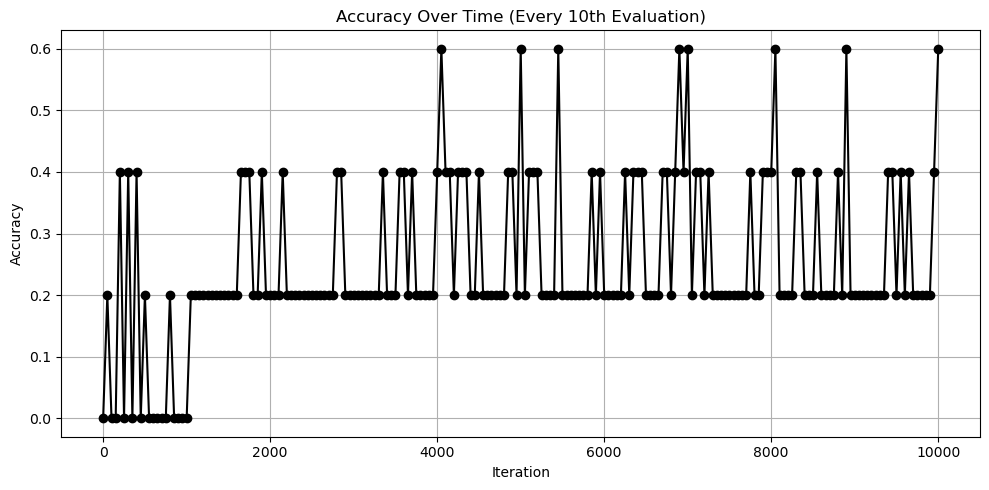

In [45]:
#plot every other iteration so we can visualise what the convergence looks like
log_df = result_higher[2]
sampled_df = log_df.iloc[::50]  # Take every 50th row
plt.figure(figsize=(10, 5))
plt.plot(sampled_df.index, sampled_df['accuracy'], marker='o', linestyle='-', color='black')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Time (Every 10th Evaluation)')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Not sure why it says 10,000 iterations as I set max_iter to 1,000
#### But tbf it does look like there is some convergence over time, it's just it's selected a solution at 40% and not 60%, why?

##### see if the 60% accuracies were more intuitive

In [49]:
filtered_result_higher = log_df[log_df['accuracy'] == 0.6]
filtered_result_higher

,coefficients,accuracy,fluxes
1032,"[-0.03924603699051205, 0.16491100791556149, 0....",0.6,"{'r_2111': 0.0, 'r_1714': 0.0, 'r_1761': 1.119..."
1033,"[-0.04245662559752654, -0.09659513682575718, 0...",0.6,"{'r_2111': 0.0, 'r_1714': 0.0, 'r_1761': 1.119..."
1049,"[-0.03102386260726282, -0.33986491014293907, 0...",0.6,"{'r_2111': 0.0, 'r_1714': 0.0, 'r_1761': 1.119..."
1059,"[-0.03986305344585459, -0.15178194599483608, 0...",0.6,"{'r_2111': 0.0, 'r_1714': 0.0, 'r_1761': 1.119..."
1068,"[0.4214047781572244, -0.0914664403133224, 0.17...",0.6,"{'r_2111': 0.0, 'r_1714': 0.0, 'r_1761': 1.119..."
...,...,...,...
9940,"[-0.2603223214958705, -0.36130822915943644, 0....",0.6,"{'r_2111': 0.0, 'r_1714': 0.0, 'r_1761': 1.119..."
9952,"[-0.295826697622493, -0.41058569100753245, 0.0...",0.6,"{'r_2111': 0.0, 'r_1714': 0.0, 'r_1761': 1.119..."
9956,"[0.16531210687057038, -0.4848509495382693, 0.1...",0.6,"{'r_2111': 0.0, 'r_1714': 0.0, 'r_1761': 1.895..."
10000,"[0.16421085035283464, -0.48162102719067357, 0....",0.6,"{'r_2111': 0.0, 'r_1714': 0.0, 'r_1761': 1.119..."


In [50]:
filtered_result_higher.iloc[0,0] #this is just an example of one which reached 60%, doesn't seem to make much sense either

[-0.03924603699051205,
 0.16491100791556149,
 0.29062221773468233,
 0.3599419119461866,
 0.14527882541305756]

In [47]:
print('criteria for faster grower:')
for k,v in criteria_higher.items():
    print(k,model.reactions.get_by_id(k).name,v,interpretation[v])

criteria for faster grower:
r_2111 growth 1 maximise
r_1714 D-glucose exchange -1 minimise
r_1761 ethanol exchange 1 maximise
r_1808 glycerol exchange 1 maximise
r_1654 ammonium exchange -1 minimise
